In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from database import get_engine

print("Imports successful!")

Imports successful!


In [2]:
engine = get_engine()

print("Pulling VIX data...")
vix = yf.download('^VIX', start='2014-01-01', end='2024-12-31', 
                  auto_adjust=True, progress=False)

vix = vix.reset_index()
vix.columns = vix.columns.get_level_values(0)
vix.columns = [c.lower() for c in vix.columns]
vix = vix[['date', 'close']].rename(columns={'close': 'vix'})
vix['date'] = pd.to_datetime(vix['date']).dt.date

# Create regime labels
vix['regime'] = pd.cut(vix['vix'], 
                        bins=[0, 20, 30, 1000],
                        labels=[0, 1, 2]).astype(int)

vix.to_sql('vix', engine, if_exists='replace', index=False)

print(f"VIX data saved — {len(vix)} rows")
print(f"\nRegime distribution:")
print(vix['regime'].value_counts().sort_index())
print(f"\nRegime 0 (Calm, VIX<20):     {(vix['regime']==0).sum()} days")
print(f"Regime 1 (Normal, VIX 20-30): {(vix['regime']==1).sum()} days")
print(f"Regime 2 (Stressed, VIX>30):  {(vix['regime']==2).sum()} days")

Pulling VIX data...
VIX data saved — 2767 rows

Regime distribution:
regime
0    1994
1     629
2     144
Name: count, dtype: int64

Regime 0 (Calm, VIX<20):     1994 days
Regime 1 (Normal, VIX 20-30): 629 days
Regime 2 (Stressed, VIX>30):  144 days


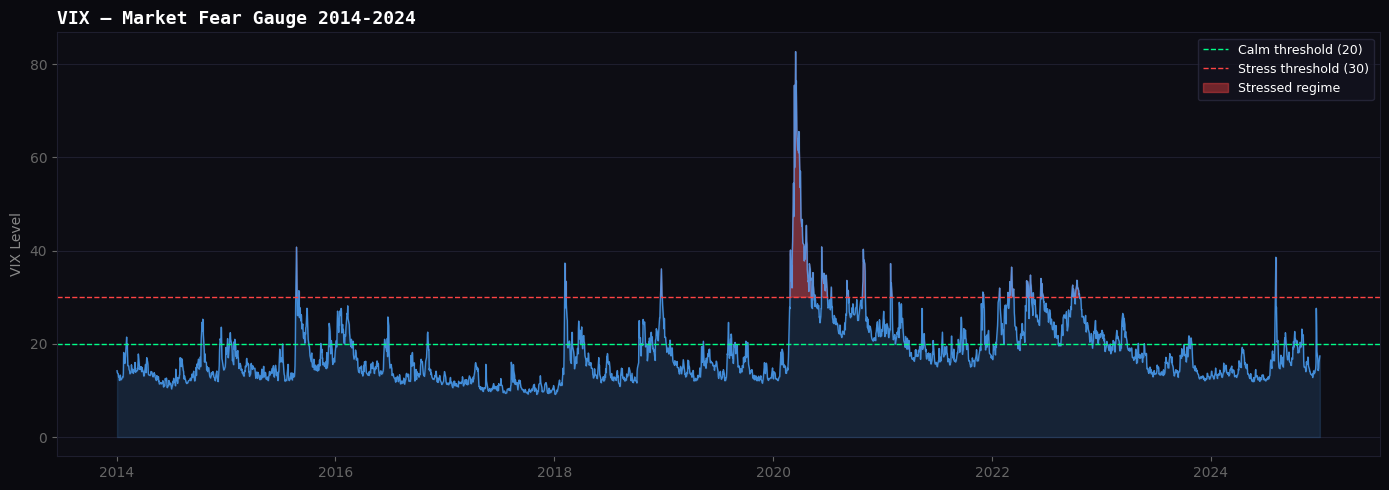

In [3]:
fig, ax = plt.subplots(figsize=(14, 5), facecolor='#0a0a0f')
ax.set_facecolor('#0d0d14')

ax.plot(vix['date'], vix['vix'], color='#4da6ff', linewidth=1, alpha=0.8)
ax.fill_between(vix['date'], vix['vix'], 0, alpha=0.15, color='#4da6ff')

ax.axhline(y=20, color='#00ff88', linewidth=1, linestyle='--', label='Calm threshold (20)')
ax.axhline(y=30, color='#ff4444', linewidth=1, linestyle='--', label='Stress threshold (30)')

ax.fill_between(vix['date'], vix['vix'], 30,
                where=vix['vix'] > 30, alpha=0.4, color='#ff4444', label='Stressed regime')

ax.set_title('VIX — Market Fear Gauge 2014-2024', color='white',
             fontsize=13, fontweight='bold', fontfamily='monospace', loc='left')
ax.set_ylabel('VIX Level', color='#888888')
ax.tick_params(colors='#666666')
ax.spines[['top','right','left','bottom']].set_color('#1e1e2e')
ax.yaxis.grid(True, color='#1e1e2e', linewidth=0.8)
ax.legend(fontsize=9, facecolor='#13131f', edgecolor='#2a2a3e', labelcolor='white')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [4]:
print("Pulling fundamental data...")

tickers_to_pull = ['AAPL', 'MSFT', 'AMZN', 'NVDA', 'GOOGL', 
                   'META', 'JPM', 'JNJ', 'XOM', 'BAC',
                   'V', 'MA', 'UNH', 'PG', 'HD']

fundamentals = []

for ticker in tickers_to_pull:
    try:
        stock = yf.Ticker(ticker)
        info  = stock.info
        
        fundamentals.append({
            'ticker':          ticker,
            'pe_ratio':        info.get('trailingPE', None),
            'pb_ratio':        info.get('priceToBook', None),
            'profit_margin':   info.get('profitMargins', None),
            'revenue_growth':  info.get('revenueGrowth', None),
            'debt_to_equity':  info.get('debtToEquity', None),
            'return_on_equity':info.get('returnOnEquity', None),
            'earnings_growth': info.get('earningsGrowth', None),
        })
        print(f"Got fundamentals for {ticker}")
    except Exception as e:
        print(f"Failed {ticker}: {e}")

fund_df = pd.DataFrame(fundamentals)
fund_df.to_sql('fundamentals', engine, if_exists='replace', index=False)
print(f"\nFundamentals saved for {len(fund_df)} stocks!")
fund_df

Pulling fundamental data...
Got fundamentals for AAPL
Got fundamentals for MSFT
Got fundamentals for AMZN
Got fundamentals for NVDA
Got fundamentals for GOOGL
Got fundamentals for META
Got fundamentals for JPM
Got fundamentals for JNJ
Got fundamentals for XOM
Got fundamentals for BAC
Got fundamentals for V
Got fundamentals for MA
Got fundamentals for UNH
Got fundamentals for PG
Got fundamentals for HD

Fundamentals saved for 15 stocks!


,ticker,pe_ratio,pb_ratio,profit_margin,revenue_growth,debt_to_equity,return_on_equity,earnings_growth
0,AAPL,36.347458,41.353996,0.27152,0.166,79.548,1.41471,0.218
1,MSFT,25.129244,7.564408,0.39342,0.183,30.271,0.34014,0.234
2,AMZN,31.633533,6.427859,0.12224,0.166,53.300,0.24285,0.748
3,NVDA,46.077713,34.814587,0.55603,0.732,7.255,1.01485,0.956
4,GOOGL,30.311687,10.041504,0.37919,0.218,20.026,0.38885,0.820
5,META,22.319403,6.397363,0.32837,0.331,35.608,0.32930,0.624
6,JPM,14.262932,2.319772,0.33936,0.127,NaN,0.16465,0.172
7,JNJ,26.239584,6.720320,0.21834,0.099,67.730,0.26416,-0.529
8,XOM,26.585857,2.544265,0.07765,0.026,18.261,0.09873,-0.434
9,BAC,12.349875,1.287244,0.28956,0.081,NaN,0.10644,0.244
